## Objectives
### Matrices
1. Enter matrices A, B, C as NumPy matrices
2. Display dimensions of A, B, C
3. Check if each operation is defined, then compute if it is:
   - (a) A + B
   - (b) AB
   - (c) AC
   - (d) C^T
4. Verify: (A + B)^T = A^T + B^T
5. Verify: (AC)^T = C^T A^T
6. Compute C^{-1}

### Image
1. Load and display week7_image.jpg with OpenCV + Matplotlib
2. Find the resolution of the image
3. Explain why the array shape has a third number

In [41]:
# Import math
import numpy as np

# For the image portion later
import cv2
import matplotlib.pyplot as plt

## Part 1: Define Matrices A, B, C

represented matrices using NumPy arrays, which are second-order tensors. This aligns with how tensors are used in machine learning and allows consistent element and matrix operations using NumPy.

In [42]:
# Define A, B, C as NumPy arrays
A = np.array([
    [1, -2,  3,  7],
    [2,  1,  1,  4],
    [-3, 2, -2, 10]
])

B = np.array([
    [0,  1, -3, -2],
    [10, -1, 2, -3],
    [5,  1, -1, 4]
])

C = np.array([
    [4, 0, -2,  3],
    [3, 6,  9,  7],
    [2, 2,  5,  1],
    [9, 4,  6, -2]
])

print("A=\n", A, "\n")
print("B=\n", B, "\n")
print("C=\n", C)

A=
 [[ 1 -2  3  7]
 [ 2  1  1  4]
 [-3  2 -2 10]] 

B=
 [[ 0  1 -3 -2]
 [10 -1  2 -3]
 [ 5  1 -1  4]] 

C=
 [[ 4  0 -2  3]
 [ 3  6  9  7]
 [ 2  2  5  1]
 [ 9  4  6 -2]]


## Step 2: Dimensions (Shapes) of A, B, C

.shape returns (rows, columns).

In [43]:
print("A:", A.shape)
print("B:", B.shape)
print("C:", C.shape)

A: (3, 4)
B: (3, 4)
C: (4, 4)


## Step 3: Check which matrix operations are defined, then compute

Rules of matricies:
- Addition: matrices must have the same shape
- Multiplication: inner dimensions must match
- Transpose is always defined

In [44]:
# (a) A + B (defined only if same shape)
print("(a) A + B")
if A.shape == B.shape:
    A_plus_B = A + B
    print("Defined. Result:\n", A_plus_B, "\n")
else:
    print("Not defined because shapes differ:", A.shape, "and", B.shape, "\n")


# (b) AB (defined only if A columns == B rows)
print("(b) AB")
if A.shape[1] == B.shape[0]:
    AB = A @ B
    print("Defined. Result:\n", AB, "\n")
else:
    print("Not defined because inner dimensions do not match.")
    print("A is", A.shape, "and B is", B.shape, "so", A.shape[1], "!=", B.shape[0], "\n")


# (c) AC (defined only if A columns == C rows)
print("(c) AC")
if A.shape[1] == C.shape[0]:
    AC = A @ C
    print("Defined. Result:\n", AC, "\n")
else:
    print("Not defined because inner dimensions do not match.")
    print("A is", A.shape, "and C is", C.shape, "so", A.shape[1], "!=", C.shape[0], "\n")


# (d) C^T (transpose is always defined)
print("(d) C^T")
CT = C.T
print("Defined. Result:\n", CT)

(a) A + B
Defined. Result:
 [[ 1 -1  0  5]
 [12  0  3  1]
 [ 2  3 -3 14]] 

(b) AB
Not defined because inner dimensions do not match.
A is (3, 4) and B is (3, 4) so 4 != 3 

(c) AC
Defined. Result:
 [[ 67  22  37 -22]
 [ 49  24  34   6]
 [ 80  48  74 -17]] 

(d) C^T
Defined. Result:
 [[ 4  3  2  9]
 [ 0  6  2  4]
 [-2  9  5  6]
 [ 3  7  1 -2]]


## Step 4: Verify (A + B)^T = A^T + B^T

We will compute both sides and check if they match exactly.

In [45]:
left = (A + B).T
right = A.T + B.T

print("Left side (A + B)^T:\n", left, "\n")
print("Right side A^T + B^T:\n", right, "\n")

print("Do they match?", np.array_equal(left, right))

Left side (A + B)^T:
 [[ 1 12  2]
 [-1  0  3]
 [ 0  3 -3]
 [ 5  1 14]] 

Right side A^T + B^T:
 [[ 1 12  2]
 [-1  0  3]
 [ 0  3 -3]
 [ 5  1 14]] 

Do they match? True


### ~ This confirms that the transpose operation distributes over matrix addition, since both sides produce identical matrices

## Step 5: Verify (AC)^T = C^T A^T

This checks the transpose of a product rule.

AC was already computed above, but we can compute again for clarity.

In [46]:
AC = A @ C

left = (AC).T
right = C.T @ A.T

print("Left side (AC)^T:\n", left, "\n")
print("Right side C^T A^T:\n", right, "\n")

print("Do they match?", np.array_equal(left, right))

Left side (AC)^T:
 [[ 67  49  80]
 [ 22  24  48]
 [ 37  34  74]
 [-22   6 -17]] 

Right side C^T A^T:
 [[ 67  49  80]
 [ 22  24  48]
 [ 37  34  74]
 [-22   6 -17]] 

Do they match? True


### ~ This confirms the transpose-of-a-product rule: the transpose distributes over multiplication only when the order of the matrices is reversed

## Step 6: Compute C^{-1}

An inverse exists only if det(C) is not zero.
We will:
1. Compute det(C)
2. Compute inv(C)
3. Verify C * C^{-1} is the identity matrix (close, due to floating point)

In [47]:
detC = np.linalg.det(C)   # The determinant tells you whether the matrix is invertible
print("det(C) =", detC)
print("det(C) is != 0 />/ det(C) is invertable")

C_inv = np.linalg.inv(C)  # computes the inverse using linear algebra
print("\nC^{-1} (decimal form):\n", C_inv)

# Verification: C @ C_inv should be the identity
I_check = C @ C_inv
print("\nC @ C^{-1} (should be identity):\n", np.round(I_check, 6))

print("\nAll close to identity?", np.allclose(I_check, np.eye(C.shape[0])))

det(C) = -540.0000000000002
det(C) is != 0 />/ det(C) is invertable

C^{-1} (decimal form):
 [[ 0.14814815 -0.07407407  0.14814815  0.03703704]
 [-0.3         0.35       -1.05        0.25      ]
 [ 0.02962963 -0.11481481  0.52962963 -0.09259259]
 [ 0.15555556  0.02222222  0.15555556 -0.11111111]]

C @ C^{-1} (should be identity):
 [[ 1.  0. -0.  0.]
 [ 0.  1. -0. -0.]
 [ 0.  0.  1. -0.]
 [ 0. -0.  0.  1.]]

All close to identity? True


### ~ ___ Since det(C) is not zero, C is invertible. The computed inverse is validated because C @ C^{-1} returns the identity matrix

## Part 2: Working with Images (OpenCV)

First load the image >> // week7_image.jpg, then convert BGR to RGB (OpenCV loads as BGR), and display it.

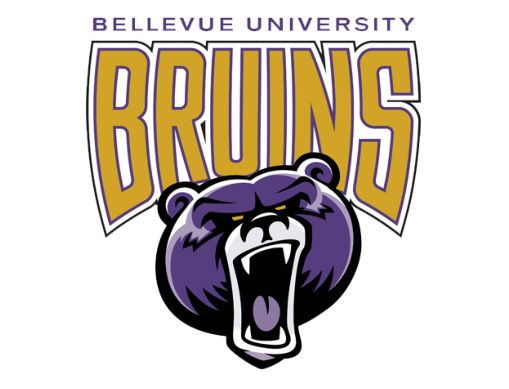

In [48]:
# Load the .jpg
image_path = "week7_image.jpg"

# Load the image (BGR format)
image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)

    

# Convert BGR to RGB for correct color display in matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display with no axis
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

## Finding the image resolution

OpenCV loads the image as a NumPy array with shape:
(height, width, channels)

Resolution is usually reported as:
width x height

In [49]:
h, w, channels = image_bgr.shape

print("Array shape:", image_bgr.shape)
print("Resolution (width x height):", f"{w} x {h}")
print("Channels:", channels)

Array shape: (453, 600, 3)
Resolution (width x height): 600 x 453
Channels: 3


## The third number in the dimensions, and its purpose

That third number is the number of color channels.

For a normal color image:
- 3 channels total
- Each pixel stores 3 values (one per channel)

OpenCV reads color images in BGR order:
- Blue channel
- Green channel
- Red channel

That is why we converted BGR to RGB before displaying with matplotlib.
Matplotlib expects RGB ordering.